In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Patch
from matplotlib.lines import Line2D
from pathlib import Path
import itables


BG    = '#F8F5F0'
DARK  = '#1C1C2E'
MID   = '#5A5A7A'
GRID  = '#E2DDD6'
WIN   = '#648FFF'
FUN   = '#DC267F'
GREEN = '#009E73'
RED   = '#D55E00'
COND_COLOR = {'FUN': FUN, 'WIN': WIN}

cm = 1 / 2.54

plt.rcParams.update({
    'figure.facecolor':  BG,
    'axes.facecolor':    BG,
    'axes.edgecolor':    GRID,
    'axes.labelcolor':   MID,
    'xtick.color':       MID,
    'ytick.color':       MID,
    'text.color':        DARK,
    'font.size':         9,
    'axes.titlesize':    10,
    'figure.dpi':        110,
    'savefig.dpi':       200,
    'savefig.facecolor': BG,
})


def style_ax(ax, title=None):
    ax.set_facecolor(BG)
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(length=3, width=0.8)
    if title:
        ax.set_title(title, fontsize=10, fontweight='bold', color=DARK, pad=8)


def paired_dot(ax, pivoted, expected='+', xjitter=0.06,
               point_size=55, line_alpha=0.55, line_lw=1.4,
               point_alpha=0.85, rng_seed=0):
    rng  = np.random.default_rng(rng_seed)
    xs   = {'WIN': 0.0, 'FUN': 1.0}
    n    = len(pivoted)
    jx_F = rng.normal(0, xjitter, n)
    jx_W = rng.normal(0, xjitter, n)

    for i, (_, row) in enumerate(pivoted.iterrows()):
        f, w = row['FUN'], row['WIN']
        if pd.isna(f) or pd.isna(w):
            continue
        diff_signed = (f - w) if expected == '+' else (w - f)
        line_color  = GREEN if diff_signed > 0 else (RED if diff_signed < 0 else MID)
        ax.plot(
            [xs['FUN'] + jx_F[i], xs['WIN'] + jx_W[i]], [f, w],
            color=line_color, alpha=line_alpha, lw=line_lw, zorder=1
        )
        ax.scatter(
            xs['FUN'] + jx_F[i], f,
            color=FUN, s=point_size, alpha=point_alpha, edgecolor='white', lw=0.6, zorder=3
        )
        ax.scatter(
            xs['WIN'] + jx_W[i], w,
            color=WIN, s=point_size, alpha=point_alpha, edgecolor='white', lw=0.6, zorder=3
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(['WIN', 'FUN'])
    ax.set_xlim(-0.45, 1.45)


def direction_legend(ax, expected_label, against_label, loc='upper right'):
    handles = [
        Line2D([0], [0], color=GREEN, lw=2, label=expected_label),
        Line2D([0], [0], color=RED,   lw=2, label=against_label),
    ]
    ax.legend(handles=handles, loc=loc, frameon=False, fontsize=8)


In [2]:
CLEAN_DIR = Path('../data')

round_data      = pd.read_csv(CLEAN_DIR / 'round.csv')
mean_round_data = pd.read_csv(CLEAN_DIR / 'mean_round.csv')
events_data     = pd.read_csv(CLEAN_DIR / 'events.csv')

groups = round_data['group'].unique()
N_PLAYERS_PER_GROUP = 5


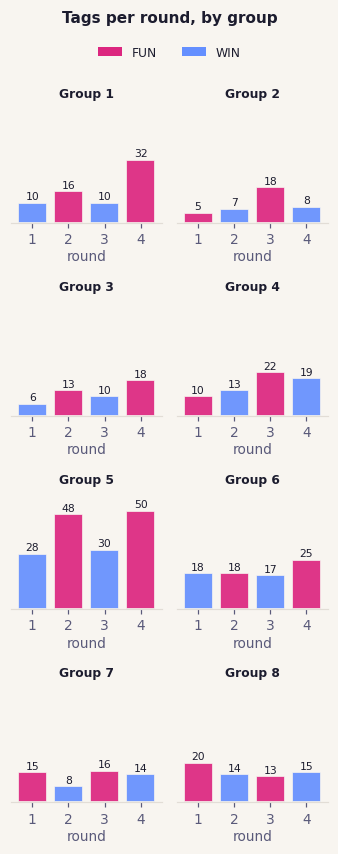

In [16]:
sorted_groups = sorted(round_data['group'].unique())
group_to_num  = {g: i + 1 for i, g in enumerate(sorted_groups)}

tags_per_round = (
    round_data
    .groupby(['group', 'round', 'condition'], as_index=False)['tags_in_round']
    .sum()
)

ncols = 2
nrows = int(np.ceil(len(sorted_groups) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(8 * cm, 19 * cm), sharey=True)
axes = np.atleast_2d(axes).ravel()

for ax, g in zip(axes, sorted_groups):
    sub    = tags_per_round[tags_per_round['group'] == g].sort_values('round')
    colors = sub['condition'].map(COND_COLOR).values
    ax.bar(sub['round'], sub['tags_in_round'],
           color=colors, edgecolor=BG, linewidth=1.2, alpha=0.92)
    for r, v in zip(sub['round'], sub['tags_in_round']):
        ax.text(r, v + 0.6, f'{int(v)}',
                ha='center', va='bottom', fontsize=7, color=DARK,
                clip_on=True)
    ax.set_xticks([1, 2, 3, 4])
    ax.set_xlabel('round', labelpad=2)
    ax.set_yticks([])
    ax.yaxis.set_visible(False)
    ax.spines['left'].set_visible(False)          
    ax.set_ylim(top=ax.get_ylim()[1] * 1.07)
    style_ax(ax, title=f'Group {group_to_num[g]}')
    ax.spines['left'].set_visible(False)          
    ax.title.set_fontsize(8)
    ax.title.set_fontweight('bold')               

for ax in axes[len(sorted_groups):]:
    ax.axis('off')

fig.legend(
    handles=[Patch(facecolor=FUN, edgecolor='none', label='FUN'),
             Patch(facecolor=WIN, edgecolor='none', label='WIN')],
    loc='upper center', bbox_to_anchor=(0.5, 1.0),
    ncol=2, frameon=False, fontsize=8
)

fig.suptitle('Tags per round, by group', fontsize=10, fontweight='bold', color=DARK, y=1.03)
fig.tight_layout()
fig.subplots_adjust(top=0.91, hspace=0.7)
plt.show()

fig.savefig('../plots/tags_per_round_by_group.png', bbox_inches='tight')

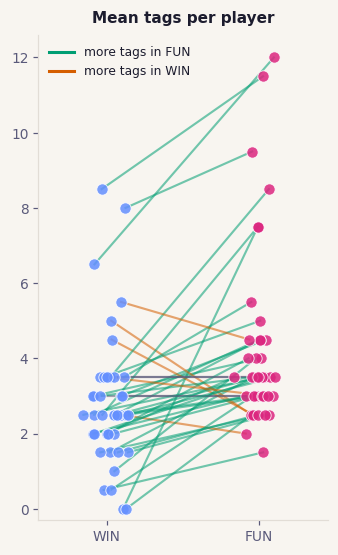

In [5]:
player_pivot = (
    mean_round_data
    .pivot(index='player_id', columns='condition', values='mean_tags_in_round')
)

fig, ax = plt.subplots(figsize=(8 * cm, 13 * cm))
paired_dot(ax, player_pivot, expected='+', xjitter=0.07)
style_ax(ax, title='Mean tags per player')
#ax.set_ylabel('Mean Tags')
ax.set_ylim(bottom=-0.3)
direction_legend(ax,
    expected_label='more tags in FUN',
    against_label ='more tags in WIN',
    loc='upper left')

fig.tight_layout()
plt.show()

fig.savefig('../plots/mean_tags_per_player_by_condition.png', bbox_inches='tight')


In [6]:
for cond in ['WIN', 'FUN']:
    vals = mean_round_data.loc[mean_round_data['condition'] == cond, 'mean_tags_in_round']
    print(f"{cond}  range {vals.min():.2f}–{vals.max():.2f}  M={vals.mean():.2f}  SD={vals.std():.2f}")

WIN  range 0.00–8.50  M=2.86  SD=1.84
FUN  range 1.50–12.00  M=4.28  SD=2.43


In [7]:
sh_pivot = (
    mean_round_data
    .pivot(index='player_id', columns='condition', values='mean_tags_in_round')
)

same  = (sh_pivot['FUN'] == sh_pivot['WIN']).sum()
more_fun = (sh_pivot['FUN'] > sh_pivot['WIN']).sum()
more_win = (sh_pivot['FUN'] < sh_pivot['WIN']).sum()

print(f"Same in both conditions: {same}")
print(f"More tags in FUN:        {more_fun}")
print(f"More tags in WIN:        {more_win}")

Same in both conditions: 4
More tags in FUN:        31
More tags in WIN:        5


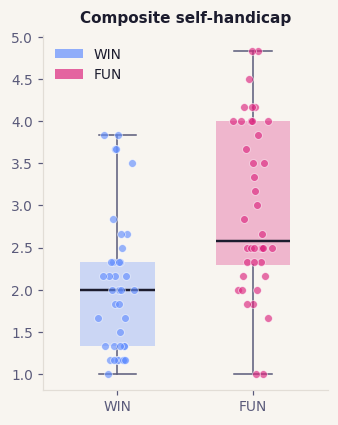

In [8]:
cond_order = [('WIN', WIN), ('FUN', FUN)]
rng = np.random.default_rng(2)

data = [
    mean_round_data.loc[
        mean_round_data['condition'] == c,
        'mean_composite_self_handicap'
    ].dropna().values
    for c, _ in cond_order
]

fig, ax = plt.subplots(figsize=(8 * cm, 10 * cm))

bp = ax.boxplot(
    data,
    positions=[0, 1],
    widths=0.55,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color=DARK, lw=1.6),
    whiskerprops=dict(color=MID, lw=1.0),
    capprops=dict(color=MID, lw=1.0),
    boxprops=dict(linewidth=0)
)

for patch, (_, color) in zip(bp['boxes'], cond_order):
    patch.set_facecolor(color)
    patch.set_alpha(0.30)

for i, (_, color) in enumerate(cond_order):
    y = data[i]
    x = i + rng.normal(0, 0.06, len(y))
    ax.scatter(x, y, color=color, alpha=0.65, s=26,
               edgecolor='white', lw=0.5, zorder=3)

ax.set_xticks([0, 1])
ax.set_xticklabels([c for c, _ in cond_order])
ax.set_xlim(-0.55, 1.55)
#ax.set_ylabel('Composite Self-Handicap Score')
style_ax(ax, title='Composite self-handicap')

ax.legend(
    handles=[Patch(facecolor=WIN, alpha=0.7, label='WIN'),
             Patch(facecolor=FUN, alpha=0.7, label='FUN')],
    loc='upper left', frameon=False, fontsize=9
)

fig.tight_layout()
plt.show()

fig.savefig('../plots/composite_self_handicap_by_condition.png', bbox_inches='tight')


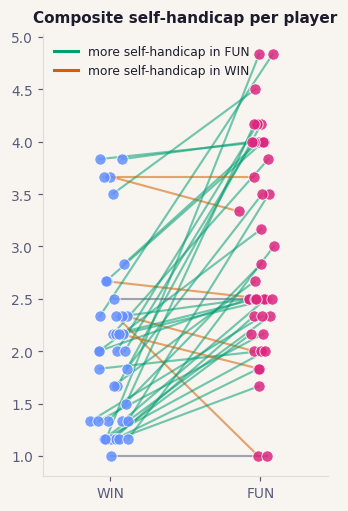

In [9]:
sh_pivot = (
    mean_round_data
    .pivot(index='player_id', columns='condition', values='mean_composite_self_handicap')
)

fig, ax = plt.subplots(figsize=(8 * cm, 12 * cm))
paired_dot(ax, sh_pivot, expected='+')
style_ax(ax, title='Composite self-handicap per player')
#ax.set_ylabel('Composite Self-Handicap Score')
direction_legend(ax,
    expected_label='more self-handicap in FUN',
    against_label ='more self-handicap in WIN',
    loc='upper left')

fig.tight_layout()
plt.show()

fig.savefig('../plots/composite_self_handicap_per_player_by_condition.png', bbox_inches='tight')
